In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from model.autoencoders import AE


In [20]:
ae = torch.load('pax_ch1_ps32_ctrl_Y_grid_00_bestmodel.pt', map_location=device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=1024, out_features=2048, bias=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv

In [51]:
recon_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/recon_00_500epochmodel_patches32_65p_20250909_1521'
os.makedirs(recon_dir, exist_ok=True)

raw_grid_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/raw_grid_00_500epochmodel_patches32_65p_20250909_1521'
os.makedirs(raw_grid_dir, exist_ok=True)

raw_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/raw_patch_00_500epochmodel_patches32_65p_20250909_1521'
os.makedirs(raw_patch_dir, exist_ok=True)

recon_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/recon_patch_00_500epochmodel_patches32_65p_20250909_1521'
os.makedirs(recon_patch_dir, exist_ok=True)




In [52]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/plot_patches32_65p_20250909_1521'
csv_filename = 'data_prep_record_49_t49.csv'

pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    

    for index, row in this_file_csv.iterrows():        
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
                
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)


        recon_patch_filename = "recon_patch_"+patch_name+'.tif'
    
        tiff.imwrite(
            os.path.join(recon_patch_dir,recon_patch_filename),
            recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )    
        
        raw_patch_img_filename = "raw_patch_"+patch_name+'.tif'
        
        tiff.imwrite(
            os.path.join(raw_patch_dir,raw_patch_img_filename),
            normed_raw_patch.astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )


        raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
        recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()


    # fig, ax = plt.subplots(1,2, figsize=(8,4))
    # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
    # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)

    recon_img_filename = "recon_"+filename+'.tif'
    
    tiff.imwrite(
        os.path.join(recon_dir,recon_img_filename),
        recon_whole_image.astype(np.float32),
        imagej=True,              # Write ImageJ metadata block
        metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    )    
    
    raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
    tiff.imwrite(
        os.path.join(raw_grid_dir,raw_grid_img_filename),
        raw_whole_image.astype(np.float32),
        imagej=True,              # Write ImageJ metadata block
        metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    )

    # break

In [36]:
y_corner1

1024

In [37]:
y_corner3

1056

In [38]:
x_corner1

864

In [39]:
x_corner3

896

In [34]:
train_latents, train_images = data_to_latents(ae, train_loader)
train_umap_latents_2d = latent_to_umap(train_latents)
train_labels = kmeans_latents(train_latents)

/tmp/ipykernel_1451127/1019363504.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


torch.Size([6586, 1, 32, 32])


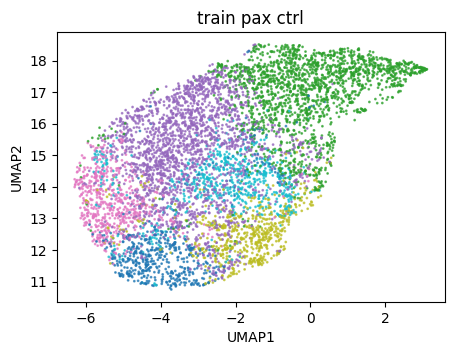

In [35]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_umap_latents_2d[:, 0], train_umap_latents_2d[:, 1], c=train_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax ctrl")
plt.show()

In [9]:
train_pax_ch1_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, train_pax_ch1_ctrl_loader)
train_pax_ch1_y_latents, train_pax_ch1_y_images = data_to_latents(ae, train_pax_ch1_y_loader)

pax_ch2_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pax_ch2_ctrl_loader)
pax_ch0_ctrl_latents, train_pax_ch1_y_images = data_to_latents(ae, pax_ch0_ctrl_loader)

pPax_ch0_ctrl_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pPax_ch0_ctrl_loader)
pPax_ch1_ctrl_latents, train_pax_ch1_y_images = data_to_latents(ae, pPax_ch1_ctrl_loader)

pPax_ch0_y_latents, train_pax_ch1_ctrl_images = data_to_latents(ae, pPax_ch0_y_loader)
pPax_ch1_y_latents, train_pax_ch1_y_images = data_to_latents(ae, pPax_ch1_y_loader)



/tmp/ipykernel_1451127/1019363504.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)


torch.Size([4205, 1, 32, 32])
torch.Size([2381, 1, 32, 32])
torch.Size([4205, 1, 32, 32])
torch.Size([4205, 1, 32, 32])
torch.Size([867, 1, 32, 32])
torch.Size([867, 1, 32, 32])
torch.Size([1345, 1, 32, 32])
torch.Size([1345, 1, 32, 32])


In [10]:

train_pax_ch1_ctrl_umap_latents_2d = latent_to_umap(train_pax_ch1_ctrl_latents)
train_pax_ch1_yy_umap_latents_2d = latent_to_umap(train_pax_ch1_y_latents)

pax_ch2_ctrl_umap_latents_2d = latent_to_umap(pax_ch2_ctrl_latents)
pax_ch0_ctrly_umap_latents_2d = latent_to_umap(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_umap_latents_2d = latent_to_umap(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_umap_latents_2d = latent_to_umap(pPax_ch1_ctrl_latents)

pPax_ch0_y_umap_latents_2d = latent_to_umap(pPax_ch0_y_latents)
pPax_ch1_y_umap_latents_2d = latent_to_umap(pPax_ch1_y_latents)

In [11]:
train_pax_ch1_ctrl_labels = kmeans_latents(train_pax_ch1_ctrl_latents)
train_pax_ch1_y_labels = kmeans_latents(train_pax_ch1_y_latents)

pax_ch2_ctrl_labels = kmeans_latents(pax_ch2_ctrl_latents)
pax_ch0_ctrly_labels = kmeans_latents(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_labels = kmeans_latents(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_labels = kmeans_latents(pPax_ch1_ctrl_latents)

pPax_ch0_y_labels = kmeans_latents(pPax_ch0_y_latents)
pPax_ch1_y_labels = kmeans_latents(pPax_ch1_y_latents)


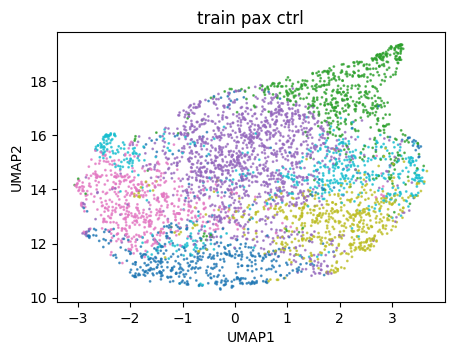

In [12]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax ctrl")
plt.show()


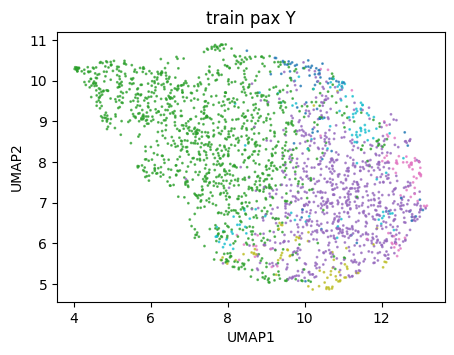

In [13]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax Y")
plt.show()

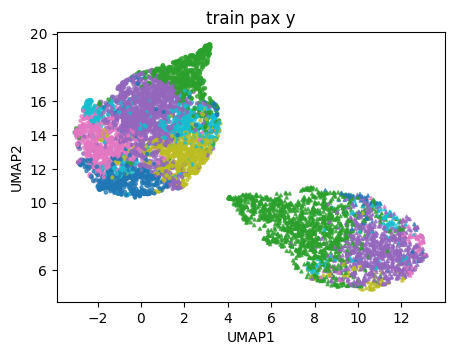

In [14]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

In [ ]:
pax_ch2_ctrl_labels = kmeans_latents(pax_ch2_ctrl_latents)
pax_ch0_ctrly_labels = kmeans_latents(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_labels = kmeans_latents(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_labels = kmeans_latents(pPax_ch1_ctrl_latents)

pPax_ch0_y_labels = kmeans_latents(pPax_ch0_y_latents)
pPax_ch1_y_labels = kmeans_latents(pPax_ch1_y_latents)


In [ ]:
train_pax_ch1_ctrl_umap_latents_2d = latent_to_umap(train_pax_ch1_ctrl_latents)
train_pax_ch1_yy_umap_latents_2d = latent_to_umap(train_pax_ch1_y_latents)

pax_ch2_ctrl_umap_latents_2d = latent_to_umap(pax_ch2_ctrl_latents)
pax_ch0_ctrly_umap_latents_2d = latent_to_umap(pax_ch0_ctrl_latents)

pPax_ch0_ctrl_umap_latents_2d = latent_to_umap(pPax_ch0_ctrl_latents)
pPax_ch1_ctrly_umap_latents_2d = latent_to_umap(pPax_ch1_ctrl_latents)

pPax_ch0_y_umap_latents_2d = latent_to_umap(pPax_ch0_y_latents)
pPax_ch1_y_umap_latents_2d = latent_to_umap(pPax_ch1_y_latents)

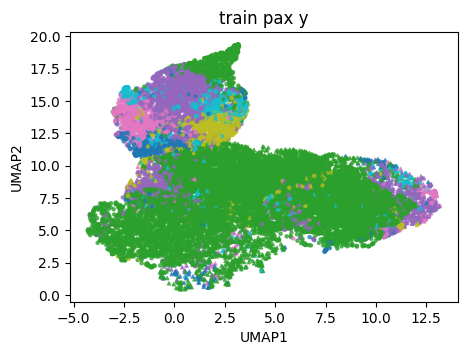

In [19]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c=train_pax_ch1_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c=train_pax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c=pax_ch2_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c=pax_ch0_ctrly_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c=pPax_ch0_ctrl_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c=pPax_ch1_ctrly_labels, cmap='tab10', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c=pPax_ch0_y_labels, cmap='tab10', alpha=0.7, s=5)
plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c=pPax_ch1_y_labels, cmap='tab10', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

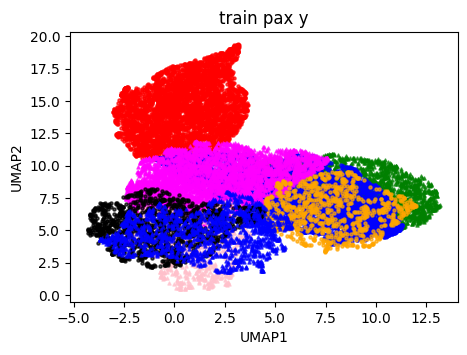

In [23]:
plt.figure(figsize=(5, 3.5))
plt.scatter(train_pax_ch1_ctrl_umap_latents_2d[:, 0], train_pax_ch1_ctrl_umap_latents_2d[:, 1], c='red', alpha=0.7, s=5)
plt.scatter(train_pax_ch1_yy_umap_latents_2d[:, 0], train_pax_ch1_yy_umap_latents_2d[:, 1], c='green', alpha=0.7, s=5, marker='^')
plt.scatter(pax_ch2_ctrl_umap_latents_2d[:, 0], pax_ch2_ctrl_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5)
plt.scatter(pax_ch0_ctrly_umap_latents_2d[:, 0], pax_ch0_ctrly_umap_latents_2d[:, 1], c='magenta', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_ctrl_umap_latents_2d[:, 0], pPax_ch0_ctrl_umap_latents_2d[:, 1], c='orange', alpha=0.7, s=5)
plt.scatter(pPax_ch1_ctrly_umap_latents_2d[:, 0], pPax_ch1_ctrly_umap_latents_2d[:, 1], c='pink', alpha=0.7, s=5, marker='^')
plt.scatter(pPax_ch0_y_umap_latents_2d[:, 0], pPax_ch0_y_umap_latents_2d[:, 1], c='black', alpha=0.7, s=5)
plt.scatter(pPax_ch1_y_umap_latents_2d[:, 0], pPax_ch1_y_umap_latents_2d[:, 1], c='blue', alpha=0.7, s=5, marker='^')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("train pax y")
plt.show()

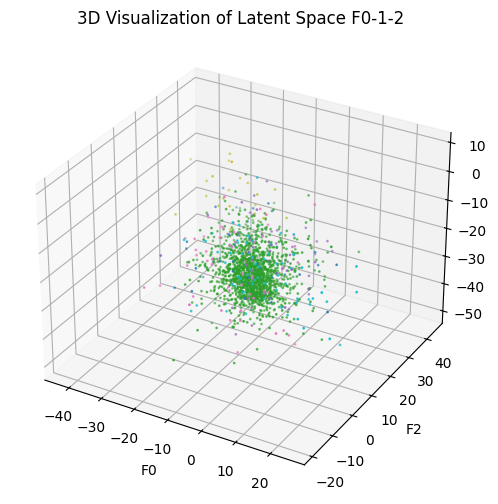

In [22]:
cluster_3Dplot(latents, 0,1,2,labels)

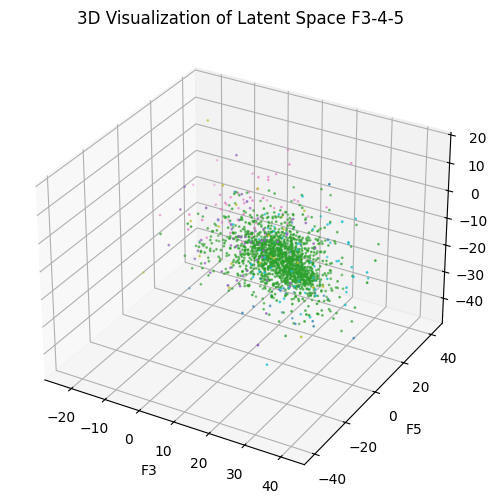

In [23]:
cluster_3Dplot(latents, 3,4,5,labels)

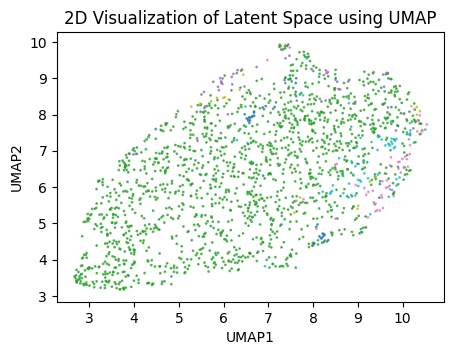

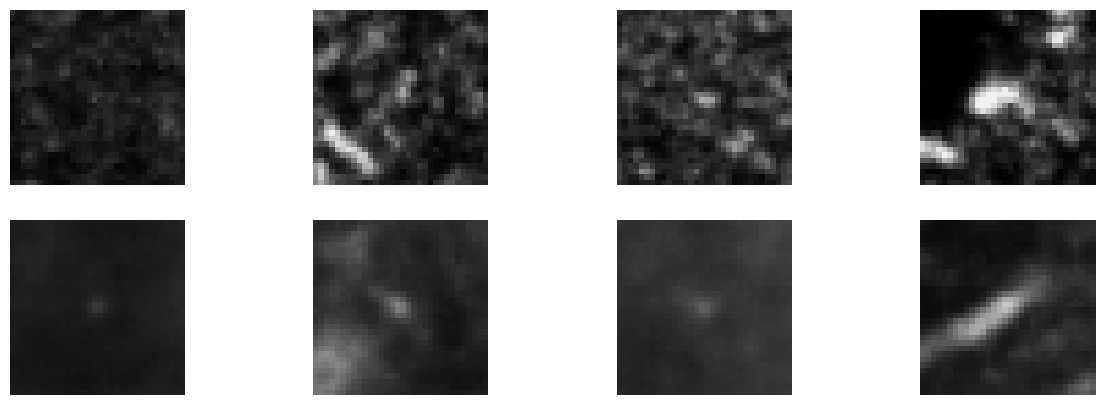

In [24]:
latents_2d = visualize_clusters(latents, labels, images, ae)


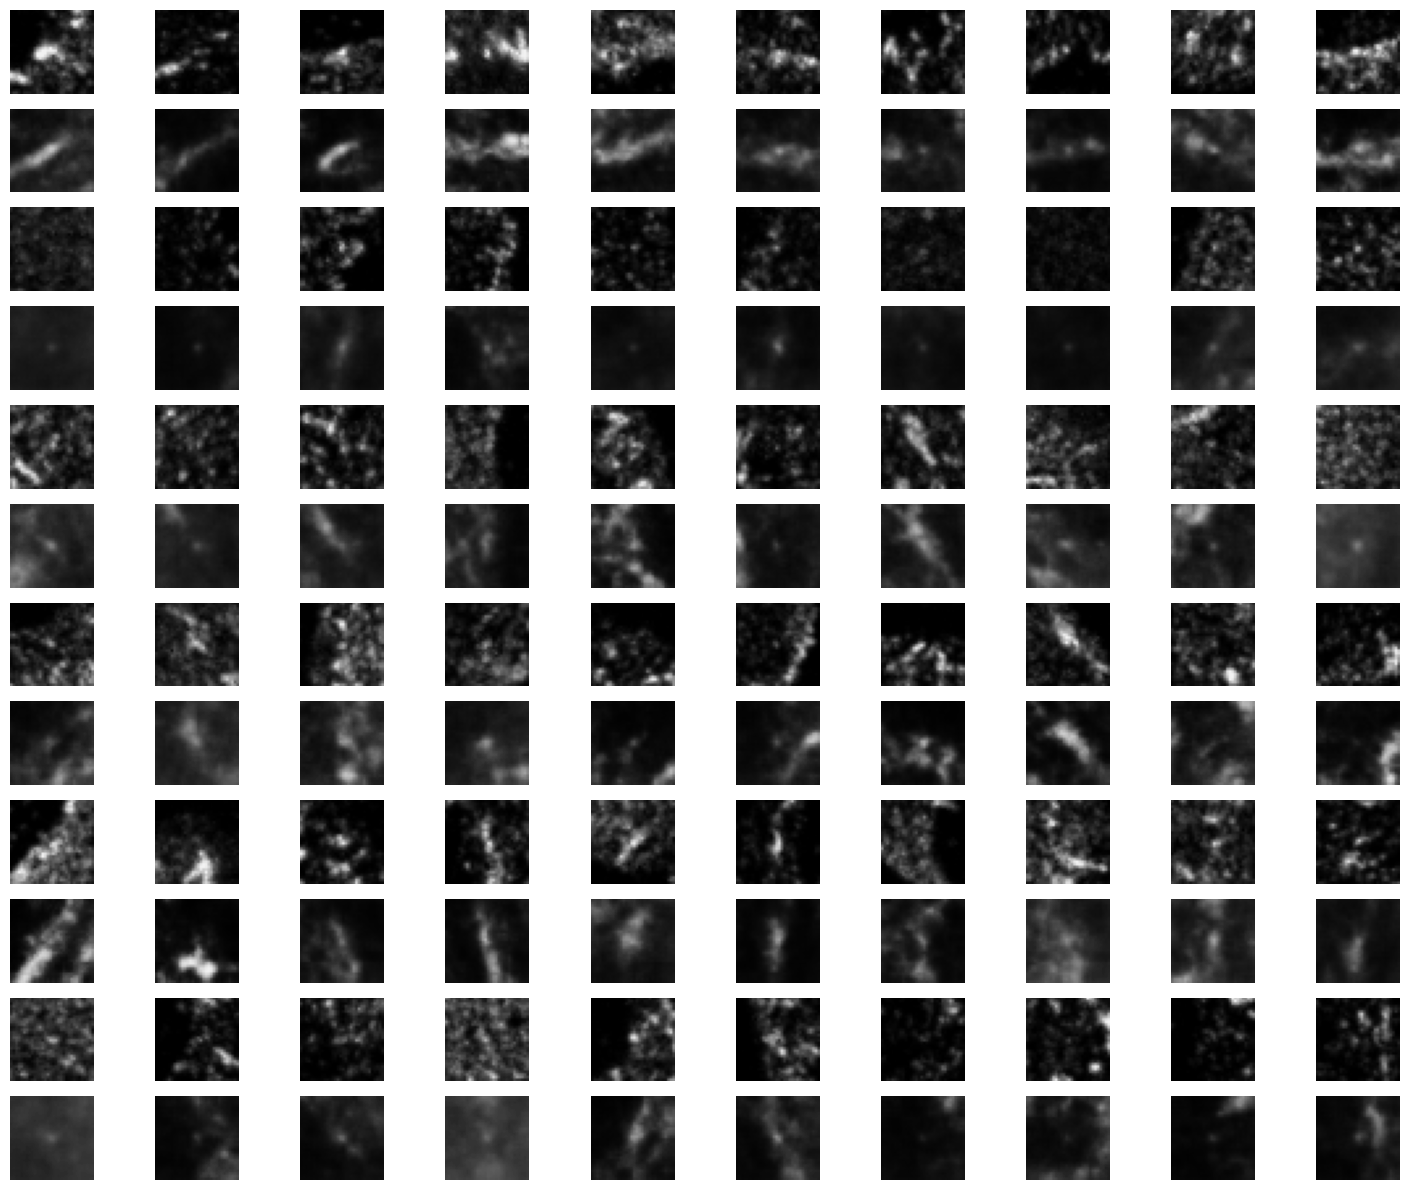

In [25]:
cluster_and_display_images(latents, labels, images, ae, num_samples_per_cluster=10)
